In [16]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

In [17]:
#Load Dataset
df = pd.read_csv("../data/ecommerce_data.csv")

df.head()

,TransactionID,CustomerID,Product,Category,Price,Quantity,PaymentType,City,Country,TransactionDate,DiscountApplied,Rating,Browser,Device,SessionDuration,CouponCode,ReturnStatus,Warehouse,ShippingType,ReviewText
0,735,1288,Dress,Electronics,59580,2,UPI,Hyderabad,India,NaN,Yes,2.925896,Chrome,Mobile,179,OFF20,NaN,WH1,NaN,Good
1,3568,1600,Headphones,NaN,73051,3,UPI,Hyderabad,India,April 5 2023,N,2.375202,Safari,Tablet,383,NaN,Returned,NaN,Standard,Good
2,2647,1750,Laptop,Fashion,41671,1,Cash,NaN,IND,NaN,No,4.847437,Safari,NaN,257,YIrSES,Not Returned,WH2,Express,NaN
3,3636,1744,Mobile,Fashion,77354,3,Cash,NaN,IND,NaN,No,1.304575,NaN,Mobile,373,YIrSES,NaN,NaN,Standard,Bad
4,2323,1246,Dress,Accessories,13351,1,Cash,Delhi,IN,2023-01-01,NaN,4.199372,Edge,Mobile,298,OFF20,Not Returned,NaN,NaN,NaN


In [18]:
#Check data information

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    5300 non-null   int64  
 1   CustomerID       5300 non-null   int64  
 2   Product          4437 non-null   str    
 3   Category         3972 non-null   str    
 4   Price            5300 non-null   int64  
 5   Quantity         5300 non-null   int64  
 6   PaymentType      4264 non-null   str    
 7   City             4281 non-null   str    
 8   Country          3941 non-null   str    
 9   TransactionDate  4015 non-null   str    
 10  DiscountApplied  4243 non-null   str    
 11  Rating           5300 non-null   float64
 12  Browser          3938 non-null   str    
 13  Device           4019 non-null   str    
 14  SessionDuration  5300 non-null   int64  
 15  CouponCode       3986 non-null   str    
 16  ReturnStatus     3498 non-null   str    
 17  Warehouse        3992 non

,TransactionID,CustomerID,Price,Quantity,Rating,SessionDuration
count,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,2496.283962,1501.120566,50272.873208,2.536415,3.001658,251.191132
std,1443.985399,290.441794,28860.385484,1.112978,1.156071,142.949875
min,1.000000,1000.000000,111.000000,1.000000,1.000891,1.000000
25%,1248.750000,1245.000000,25105.000000,2.000000,2.004778,129.000000
50%,2495.500000,1501.000000,50745.500000,3.000000,2.993256,250.000000
75%,3746.250000,1757.000000,75561.000000,4.000000,3.998908,376.000000
max,5000.000000,1999.000000,99981.000000,4.000000,4.999242,499.000000


In [19]:
#Data Cleaning
1.#Missing Values
df.isnull().sum()

TransactionID         0
CustomerID            0
Product             863
Category           1328
Price                 0
Quantity              0
PaymentType        1036
City               1019
Country            1359
TransactionDate    1285
DiscountApplied    1057
Rating                0
Browser            1362
Device             1281
SessionDuration       0
CouponCode         1314
ReturnStatus       1802
Warehouse          1308
ShippingType       1762
ReviewText         1288
dtype: int64

In [20]:
#Fill missing values:

df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['ShippingType'] = df['ShippingType'].fillna("Standard")
df['Warehouse'] = df['Warehouse'].fillna("WH1")
df['ReviewText'] = df['ReviewText'].fillna("No Review")

In [21]:
#2. Remove Duplicate Rows
df = df.drop_duplicates()

In [22]:
#3. Fix Wrong Formats
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')


In [23]:
#4. Handle Inconsistent Data
df['Product'] = df['Product'].str.lower()
df['Category'] = df['Category'].str.lower()

In [24]:
#Exploratory Data Analysis
#Top selling products
df['Product'].value_counts()

Product
shoes         853
dress         840
headphones    830
laptop        828
mobile        826
Name: count, dtype: int64

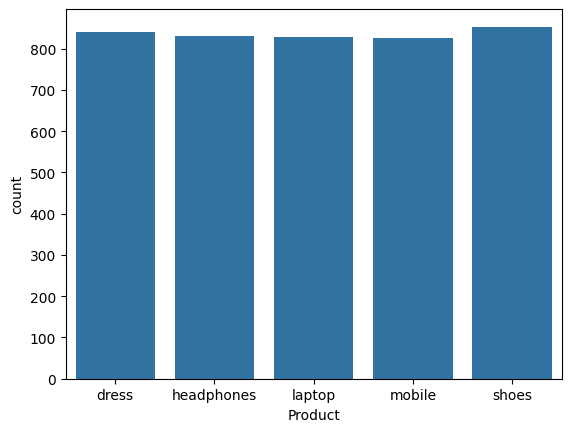

In [25]:
#Visualization
sns.countplot(x='Product', data=df)
plt.show()

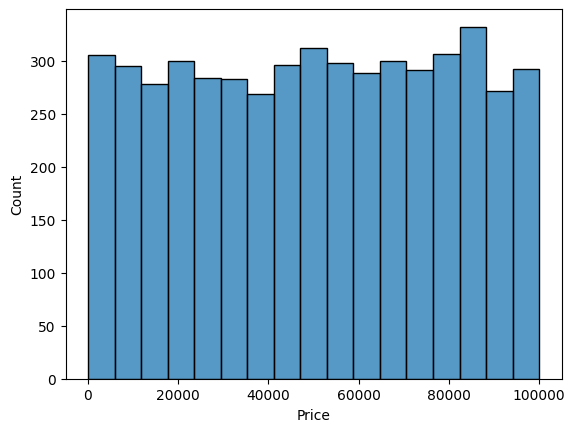

In [26]:
#Customer purchase distribution
sns.histplot(df['Price'])
plt.show()

In [27]:
#Feature Engineering
#Create customer behaviour features

customer_df = df.groupby('CustomerID').agg({

'Price':'mean',
'Quantity':'sum',
'SessionDuration':'mean',
'Rating':'mean'

}).reset_index()

In [28]:
#Rename columns

customer_df.columns = ['CustomerID','AvgSpend','TotalItems','AvgSession','AvgRating']

In [29]:
#Feature Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_df.drop('CustomerID',axis=1))


In [30]:
#Customer Segmentation (Clustering)
#1.K-Means Clustering
kmeans = KMeans(n_clusters=4)

customer_df['Cluster_KMeans'] = kmeans.fit_predict(scaled_data)

In [31]:
#Evaluate

silhouette_score(scaled_data, customer_df['Cluster_KMeans'])

0.19585079203808173

In [32]:
#2️⃣ Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=4)

customer_df['Cluster_HC'] = hc.fit_predict(scaled_data)

In [33]:
#3️⃣ DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

customer_df['Cluster_DBSCAN'] = dbscan.fit_predict(scaled_data)

In [34]:
#4️⃣ Gaussian Mixture Model
gmm = GaussianMixture(n_components=4)

customer_df['Cluster_GMM'] = gmm.fit_predict(scaled_data)

In [35]:
#Save Customer Segments
customer_df.to_csv("../results/customer_segments.csv",index=False)

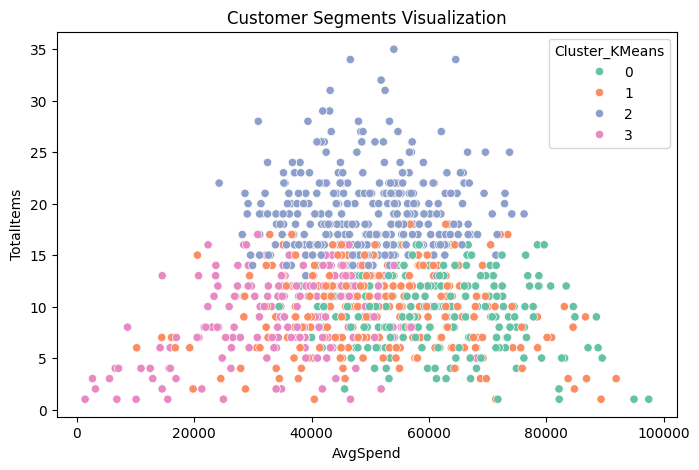

In [36]:
#cluster_visualization.png
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_df, x='AvgSpend', y='TotalItems', hue='Cluster_KMeans', palette='Set2')
plt.title("Customer Segments Visualization")
plt.savefig("../results/cluster_visualization.png")
plt.show()

In [39]:
print(type(basket))

<class 'pandas.DataFrame'>


In [38]:
#Association Rule Mining (Product Recommendation)
#We create transaction matrix.

#Convert to Basket Format
basket = pd.crosstab(df['TransactionID'], df['Product'])


basket = (basket > 0)


In [40]:
#Apriori Algorithm
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

# Generate Rules
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

# Sort rules
rules = rules.sort_values(by='lift', ascending=False)

# Show top rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

rules.head()
#Example output:

#mobile → earphones
#dress → heels
#laptop → mouse

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [41]:
#Check basket
print(basket.head())

Product        dress  headphones  laptop  mobile  shoes
TransactionID                                          
1               True       False   False   False  False
2              False       False    True   False  False
3               True       False   False   False  False
4              False       False   False    True  False
5              False       False    True   False  False


In [42]:
#save rules
rules.to_csv("../association_rules/apriori_rules.csv", index=False)



In [46]:
#FP-Growth
fp_items = fpgrowth(basket, min_support=0.02, use_colnames=True)

fp_rules = association_rules(fp_items, metric="lift", min_threshold=1)

fp_rules.to_csv("../association_rules/fp_growth_rules.csv")

In [47]:
#ECLAT
from mlxtend.frequent_patterns import apriori

eclat_items = apriori(basket, min_support=0.02, use_colnames=True)

eclat_rules = association_rules(eclat_items, metric="confidence", min_threshold=0.5)

eclat_rules.to_csv("../association_rules/eclat_rules.csv")

In [45]:
# STEP 10: Save Models
import os
import pickle

# Create models folder if not exists
os.makedirs("../models", exist_ok=True)

# Save KMeans
with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save Hierarchical Clustering
with open("../models/hierarchical_model.pkl", "wb") as f:
    pickle.dump(hc, f)

# Save DBSCAN
with open("../models/dbscan_model.pkl", "wb") as f:
    pickle.dump(dbscan, f)

# Save Gaussian Mixture Model
with open("../models/gmm_model.pkl", "wb") as f:
    pickle.dump(gmm, f)

print("All models saved successfully!")

All models saved successfully!
